In [1]:
import numpy as np
from ase.io import read
from ase.visualize import view
from ase.db import connect
import sys
import pandas as pd
import matplotlib.pyplot as plt
import copy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection  import train_test_split
from scipy.optimize import least_squares, minimize, basinhopping

# from Helper_SurfEP_DirectFit_Dev import exportHostModel

#sys.path.append("/Users/Matt/pythonScripts/montemoregroup/src/montegroup/")
sys.path.append("/Users/hajar/Downloads/montemoregroup1/src/montegroup")
# from surfEP import surfEP
from ghit import GHIT
from coordsFunctions import snapCoords,findNeighborIndices

In [2]:
import importlib
import gnn_framework_Mace
importlib.reload(gnn_framework_Mace)

from gnn_framework_Mace import GNNModel, GraphSample

In [3]:
import sys
print(sys.executable)

/opt/anaconda3/envs/gcnn_safe_cpu/bin/python


In [4]:
import sys
!{sys.executable} -m pip install mace-torch

In [4]:
from mace.calculators import mace_mp

/opt/anaconda3/envs/gcnn_safe_cpu/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [5]:
def setup_mace_calculator(model="medium", device=None):
    """
    Set up the MACE-MP calculator.
    """
    if device is None:
        device = "cpu"
    
    print(f"Setting up MACE-MP calculator with model='{model}' on device='{device}'")
    
    # Initialize MACE-MP calculator
    calc = mace_mp(model=model, device=device)
    
    return calc

In [6]:
### All input for data section should go here

### databases that already know the host binding atoms
databaseDir1 = '/Users/hajar/Downloads/Databases_PW91/'

databaseNames1 = ['hAdsProcessed.db','FProcessed.db','KProcessed.db',
               'nhxProcessed.db','nhxProcessed.db',
               'shxProcessed.db','shxProcessed.db',
               'chxProcessed.db','chxProcessed.db', 'chxProcessed.db','chxProcessed.db',
               'oxAdsProcessed.db','oxAdsProcessed.db','oxAdsProcessed.db','coProcessed.db'
                ]

databaseList1 = [connect(databaseDir1+databaseName) for databaseName in databaseNames1]

importGuestList1 = ['H','F','K',
                   'N','NH2',
                   'S','SH',
                   'C','Methyl', 'Methylene','Methylidyne', 
                   'O','Hydroxyl','Methoxy','CO'
                  ]

### databases that don't know the host binding atoms

#databaseDir2 = '/Users/Matt/Dropbox/Data/Databases_PW91/'

databaseDir2 = '/Users/hajar/Downloads/Databases_PW91/'
databaseNames2 = ['DissFinal.db','DissFinal.db','DissFinal.db','DissFinal.db',
                  'DissFinal.db','DissFinal.db','DissFinal.db','MoreMethylTop_Processed.db','MoreOH_Processed.db']
databaseList2 = [connect(databaseDir2+databaseName) for databaseName in databaseNames2]
importGuestList2 = ['CH4TS','CH3TS','CH2TS','CHTS',
                    'OHTS','H2OTS','COTS', 'Methyl','Hydroxyl']
gasPhaseEnList2 = [-24.091421,-18.176726,-12.058483,-6.102109,-7.579404,-14.26184735,-14.82331288,None,None]

bareSurfNewDB = connect(databaseDir2+'MSRNew12.db') 
bareSurfNew2DB = connect(databaseDir2+'bareSurfNew.db')

In [7]:
### Get adsorption energy, binding site, binding elements, etc. Put in datafram (df)

d = []
atomsList = []

for database,inputGuest in zip(databaseList1,importGuestList1):
    for row in database.select():
#         print(row.get('guest_name'))
        if 'NiPt' in row.get('directory') or 'Sandwich' in row.get('directory') or 'HydrogenTi3inOs' in row.get('directory') or 'NH2ReonPt' in row.get('directory') or 'Step' in row.get('directory'):
            print(row.get('directory')+' skipped')
            continue
        if row.get('guest_name') != inputGuest:
            continue
        if 'Sn' in row.get('symbols') or 'Zn' in row.get('symbols'):
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
#         if symbols[0] != inputGuest: print('WARNING: Code probably went wrong because '+'guestAtom'+' is not first atom.')
        ghit = GHIT(row.toatoms())
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        print(ghit)
        print(row)
        try:
            host_binding_atoms_bare = row.data.get('atoms_adsorbed_to')
            ### TODO: Fix next line. It will almost certainly cause problems at some point. Should probably just detect host binding atoms in all cases.
            host_binding_atoms_adsorbed = np.array(host_binding_atoms_bare) + len(ghit.get_guest_atoms())
        except (ValueError, AttributeError):
            ghit.find_host_binding_atoms()
            host_binding_atoms_adsorbed = ghit.get_host_binding_atoms()[0]
        

        print(ghit.get_guest_atoms())
#         ghit.host_binding_atoms()
#         host_binding_atoms = ghit.get_host_binding_atoms()[0]
#         print(host_binding_atoms)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
#         print(symbols[row.data.get('atoms_adsorbed_to')+1])
        #print(row.__dict__)
        #host_binding_atoms_bare = np.array(host_binding_atoms_bare,dtype='int')
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':row.get('adsorption_energy'),
                  'site_name':row.get('site_name'), 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed})

for database,inputGuest,gasPhaseEn in zip(databaseList2,importGuestList2,gasPhaseEnList2):
    for row in database.select():
#         print(row.get('guest_name'), row.get('host_name'))
        if row.get('guest_name') != inputGuest:
            continue
        print(row.get('directory'))
        print(row.get('guest_name'))
        siteName = 'top' ### BIG ASSUMPTION!!!!! TODO: FIX THIS!!!!
        atoms = row.toatoms()
        atoms.set_pbc(True)
        atomsList.append(atoms)
        symbols = np.array(atoms.get_chemical_symbols())
        ghit = GHIT(row.toatoms())
        ghit.set_pbc(True)
#         ghit.wrap(center=ghit.positions[0])
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        print('all guest:',ghit.get_guest_atoms())
        ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5,check_saturation=True)
        print('gba',ghit.get_guest_binding_atoms())
        ghit.set_binding_sites(['ontop' for at in ghit.get_guest_binding_atoms()])
        ghit.find_host_binding_atoms()
        print(ghit.get_binding_sites())
        select_hba = [0]
        host_binding_atoms_adsorbed = np.array([item for sublist in ghit.get_host_binding_atoms() for item in sublist])[select_hba]
        print(host_binding_atoms_adsorbed)
        host_binding_elements = symbols[list(host_binding_atoms_adsorbed)]
        

        if gasPhaseEn is None: 
            adsEn = row.get('adsorption_energy')
        else:
            try:
                bareSurfRow = bareSurfNewDB.get('guest_name=BareSurf,host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn
            except KeyError:
                bareSurfRow = bareSurfNew2DB.get('host_name='+row.get('host_name')) #
                adsEn = row.get('energy') - bareSurfRow.get('energy') - gasPhaseEn               
        d.append({'directory':row.get('directory')[40:],'adsorption_energy':adsEn,
                  'site_name':siteName, 'host_name':row.get('host_name'),
                'guest_name':row.get('guest_name'),'host_binding_elements':host_binding_elements,
                 'host_binding_atoms_ads':host_binding_atoms_adsorbed,
                 'guest_binding_atoms':ghit.get_guest_binding_atoms(), 
                 })
        
df = pd.DataFrame(d)

/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/Bridge
H
GHIT(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36H, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OxAds//HydrogenAg/FHollow
H
GHIT(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36H, keys=site_name,adsorption_energy,host_name,dir

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurAg/Bridge
S
GHIT(symbols='SAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36S, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurAg/FHollow
S
GHIT(symbols='SAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], guest_atoms=..., host_atoms=..., masses=..., momenta=..., tags=..., calculator=SinglePointCalculator(...))
<AtomsRow: formula=Ag36S, keys=site_name,adsorption_energy,host_name,directory,guest_name>
[0]
/Users/Matt/Dropbox/Data/CUBackupData/VASPonShared/Done/OtherAds/SulfurAg/HHollow
S
GHIT(symbols='SAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissCr_Cu
CH4TS
all guest: [36 37 38 39 40]
gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissFe_Cu
CH4TS
all guest: [36 37 38 39 40]
gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissHf_Ag
CH4TS
all guest: [0 1 2 3 4]
gba [0 3]
['ontop' 'ontop']
[11]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissHf_Cu
CH4TS
all guest: [36 37 38 39 40]
gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissMn_Cu
CH4TS
all guest: [36 37 38 39 40]
gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissNb_Ag
CH4TS
all guest: [0 1 2 3 4]
gba [0 3]
['ontop' 'ontop']
[11]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissNi_Cu
CH4TS
all guest: [36 37 38 39 40]
gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Databases_PW91/CH4Diss/CH4DissPd_Cu
CH4TS
all guest: [36 37 38 39 40]
gba [36 39]
['ontop' 'ontop']
[6]
/Users/Sarah/Lab/Datab

In [8]:
print(len(df),len(atomsList))
display(df[df['guest_name'].str.contains("OH")]) #[['formulas','error','adsorption_energy','pred_adsorption_energy']]
print(d[1478])

1776 1776
The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.


,directory,adsorption_energy,site_name,host_name,guest_name,host_binding_elements,host_binding_atoms_ads,guest_binding_atoms
1467,/PyMatGenStuff/MSRProject/OHDissociation/OHDissNi,-2.481004,top,Ni,OHTS,[Ni],[7],"[0, 1]"
1468,/PyMatGenStuff/MSRProject/OHDissociation/OHDissRu,-2.674866,top,Ru,OHTS,[Ru],[6],"[0, 1]"
1469,/PyMatGenStuff/MSRProject/OHDissociation/OHDissRh,-2.139037,top,Rh,OHTS,[Rh],[9],"[0, 1]"
1470,/PyMatGenStuff/MSRProject/OHDissociation/OHDissAg,-0.400234,top,Ag,OHTS,[Ag],[7],"[0, 1]"
1471,/PyMatGenStuff/MSRProject/OHDissociation/OHDissAu,-0.070451,top,Au,OHTS,[Au],[8],"[0, 1]"
1472,/PyMatGenStuff/MSRProject/OHDissociation/OHDissCu,-1.683246,top,Cu,OHTS,[Cu],[7],"[0, 1]"
1473,/PyMatGenStuff/MSRProject/OHDissociation/OHDissIr,-1.550183,top,Ir,OHTS,[Ir],[8],"[0, 1]"
1474,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPd,-1.207190,top,Pd,OHTS,[Pd],[10],"[0, 1]"
1475,/PyMatGenStuff/MSRProject/OHDissociation/OHDissPt,-1.428230,top,Pt,OHTS,[Pt],[8],"[0, 1]"
1476,/PyMatGenStuff/MSRProject/OHDissociation/OHDis...,-1.892880,top,Ir_Ag,OHTS,[Ir],[8],"[0, 1]"


{'directory': '/PyMatGenStuff/MSRProject/OHDissociation/OHDissTi_Ag', 'adsorption_energy': -4.027679169999995, 'site_name': 'top', 'host_name': 'Ti_Ag', 'guest_name': 'OHTS', 'host_binding_elements': array(['Ti'], dtype='<U2'), 'host_binding_atoms_ads': array([8]), 'guest_binding_atoms': array([0, 1])}


In [9]:
rowNum = 1485 #1473 #1478
#bareDB = connect('/Users/Matt/Dropbox/Data/Databases_PW91/bareSurfNew.db') #MoreBare.db, MSRNew12.db, bareSurfNew.db, bareSurfClean.db
bareDB = connect('/Users/hajar/Downloads/Databases_PW91/bareSurfNew.db')
display(df.iloc[rowNum])
adsAtomsTemp = atomsList[rowNum]

try: print('mag mom ads:', adsAtomsTemp.get_magnetic_moment())
except Exception: print('no mag mom ads')
# print('energy ads',adsAtomsTemp.get_potential_energy())
adsAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(adsAtomsTemp)

bareSurfRow = bareDB.get('host_name='+df.iloc[rowNum]['host_name']) #guest_name=BareSurf or None
try: print(bareSurfRow.get('directory')[-30:])
except KeyError: print('no dir')

try: print('mag mom bare:', bareDB.get_magnetic_moment())
except Exception: print('no mag mom bare')
# print('energy bare',bareAtomsTemp.get_potential_energy())
bareAtomsTemp = bareSurfRow.toatoms()
bareAtomsTemp.wrap(center = (0.3,0.3,0.8))
# view(bareAtomsTemp)

directory                 issRu_Cu
adsorption_energy        -1.914379
site_name                      top
host_name                    Ru_Cu
guest_name                    OHTS
host_binding_elements         [Ru]
host_binding_atoms_ads         [6]
guest_binding_atoms       [36, 37]
Name: 1485, dtype: object

no mag mom ads
ses_PW91/CH4Diss/BareSurfRu_Cu
no mag mom bare


In [10]:
dropList = [1629, 1550, 1691, 1692, 1551, 1593, 1552, 1592, 1591, 
            1594, 1595, 1629, 1693, 1696, 1697, 1698, 1708, 847, 848, 1554, 1628] 
dropList = list(np.sort(np.unique(dropList))[::-1])

df.iloc[dropList]

df.drop(dropList,inplace=True)
print(len(df))

for num in dropList:
    del atomsList[num]
    
len(atomsList), len(dropList)

df.reset_index(drop=True, inplace=True) 

1756


In [11]:
df.loc[1492]

directory                 /PyMatGenStuff/MSRProject/H2ODissociation/H2OD...
adsorption_energy                                                  0.959284
site_name                                                               top
host_name                                                                Cu
guest_name                                                            H2OTS
host_binding_elements                                                  [Cu]
host_binding_atoms_ads                                                 [11]
guest_binding_atoms                                                  [0, 1]
Name: 1492, dtype: object

In [12]:
dfOrig = copy.deepcopy(df)
df = dfOrig.loc[(dfOrig['adsorption_energy']<2.5)&(dfOrig['adsorption_energy']>-20)]
print(len(df))

# Keep atomsList in sync with the filtered dataframe
atomsListOrig = copy.deepcopy(atomsList)
atomsList = [atomsListOrig[i] for i in df.index]
# Reset dataframe index to match atomsList ordering
df.reset_index(drop=True, inplace=True)

1750


In [13]:
atomsList[0]

Atoms(symbols='HAg36', pbc=True, cell=[[8.821528443, 0.0, 0.0], [4.410764221, 7.639667299, 0.0], [0.0, 0.0, 24.009156537]], constraint=FixAtoms(indices=[19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]), calculator=SinglePointCalculator(...))

In [14]:
def make_edge_list(atoms, verbose=False):
    """
    Create an edge list suitable for a convolutional graph neural network.
    Edges are classified as:
    - 'SS': surface-surface (host-host connections)
    - 'AA': adsorbate-adsorbate (guest-guest connections)
    - 'SA_bond': surface-adsorbate bond (binding connections between host and guest)
    
    Uses GHIT to identify guest atoms and binding pairs.
    Uses ASE NeighborList with adaptive cutoffs for surface atoms based on second-nearest neighbors.
    
    Parameters:
    - verbose: If True, prints cutoffs per element and neighbor counts per atom.
    """
    from ase.neighborlist import NeighborList
    from ase.data import covalent_radii
    from collections import defaultdict
    import numpy as np
    
    # Initialize GHIT and find atoms
    ghit = GHIT(atoms)
    ghit.find_guest_atoms(guest_elements=['C', 'O', 'H', 'N', 'F', 'S', 'K'])
    guest_atoms = set(ghit.get_guest_atoms())
    host_atoms = set(range(len(atoms))) - guest_atoms
    
    # Find binding atoms for SA_bond
    ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5, check_saturation=True)
    ghit.find_host_binding_atoms()
    
    guest_binding = ghit.get_guest_binding_atoms()
    host_binding_lists = ghit.get_host_binding_atoms()
    
    # Create SA_bond edges (undirected)
    sa_edges = []
    for gb, hb_list in zip(guest_binding, host_binding_lists):
        for hb in hb_list:
            sa_edges.append((min(gb, hb), max(gb, hb), 'SA_bond'))
    
    # Create cutoffs
    symbols = atoms.get_chemical_symbols()
    cutoffs = []
    host_indices = list(host_atoms)
    for i in range(len(atoms)):
        if i in host_atoms:
            # Adaptive cutoff based on second-nearest surface neighbor
            dists = atoms.get_distances(i, host_indices, mic=True)
            sorted_dists = sorted(dists)
            second_nn = sorted_dists[1]  # Second smallest distance (first is 0)
            cutoffs.append(1.05 * second_nn  * 0.5) # 0.5 for diameter to radius
        else:
            # Fixed cutoff for guest atoms
            cutoffs.append(covalent_radii[atoms[i].number] * 1.1 + 0.1)
    
    if verbose:
        # Print cutoffs per element for troubleshooting (approximate for guests)
        cutoff_dict = defaultdict(list)
        for i, cutoff in enumerate(cutoffs):
            element = symbols[i]
            cutoff_dict[element].append(cutoff)
        print("Neighbor cutoffs per element (surface: adaptive, guest: fixed):")
        for element in sorted(cutoff_dict.keys()):
            cuts = cutoff_dict[element]
            if len(cuts) == 1:
                print(f"  {element}: {cuts[0]:.3f} Å")
            else:
                print(f"  {element}: {min(cuts):.3f} - {max(cuts):.3f} Å")
    
    nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
    nl.update(atoms)
    
    edges = []
    for i in range(len(atoms)):
        neighbors = nl.get_neighbors(i)[0]
        for j in neighbors:
            if i < j:  # Avoid duplicates
                if i in host_atoms and j in host_atoms:
                    edges.append((i, j, 'SS'))
                elif i in guest_atoms and j in guest_atoms:
                    edges.append((i, j, 'AA'))
    
    if verbose:
        print("Neighbor counts per atom:")
        for i in range(len(atoms)):
            count = len(nl.get_neighbors(i)[0])
            print(f"  Atom {i} ({symbols[i]}): {count} neighbors")
    
    # Combine all edges
    edges.extend(sa_edges)
    return edges

In [15]:
make_edge_list(atomsList[10],verbose=True)

Neighbor cutoffs per element (surface: adaptive, guest: fixed):
  Au: 1.507 - 1.534 Å
  H: 0.441 Å
  Ti: 1.446 - 1.474 Å
Neighbor counts per atom:
  Atom 0 (H): 1 neighbors
  Atom 1 (Au): 10 neighbors
  Atom 2 (Au): 9 neighbors
  Atom 3 (Au): 9 neighbors
  Atom 4 (Ti): 9 neighbors
  Atom 5 (Ti): 9 neighbors
  Atom 6 (Ti): 9 neighbors
  Atom 7 (Ti): 9 neighbors
  Atom 8 (Ti): 9 neighbors
  Atom 9 (Ti): 9 neighbors
  Atom 10 (Ti): 12 neighbors
  Atom 11 (Ti): 12 neighbors
  Atom 12 (Ti): 12 neighbors
  Atom 13 (Ti): 12 neighbors
  Atom 14 (Ti): 12 neighbors
  Atom 15 (Ti): 12 neighbors
  Atom 16 (Ti): 12 neighbors
  Atom 17 (Ti): 12 neighbors
  Atom 18 (Ti): 12 neighbors
  Atom 19 (Ti): 12 neighbors
  Atom 20 (Ti): 12 neighbors
  Atom 21 (Ti): 12 neighbors
  Atom 22 (Ti): 12 neighbors
  Atom 23 (Ti): 12 neighbors
  Atom 24 (Ti): 12 neighbors
  Atom 25 (Ti): 12 neighbors
  Atom 26 (Ti): 12 neighbors
  Atom 27 (Ti): 12 neighbors
  Atom 28 (Ti): 9 neighbors
  Atom 29 (Ti): 9 neighbors
  Ato

/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


[(1, np.int64(6), 'SS'),
 (1, np.int64(8), 'SS'),
 (1, np.int64(14), 'SS'),
 (1, np.int64(4), 'SS'),
 (1, np.int64(5), 'SS'),
 (1, np.int64(7), 'SS'),
 (1, np.int64(9), 'SS'),
 (1, np.int64(10), 'SS'),
 (1, np.int64(15), 'SS'),
 (2, np.int64(4), 'SS'),
 (2, np.int64(5), 'SS'),
 (2, np.int64(6), 'SS'),
 (2, np.int64(7), 'SS'),
 (2, np.int64(8), 'SS'),
 (2, np.int64(9), 'SS'),
 (2, np.int64(11), 'SS'),
 (2, np.int64(12), 'SS'),
 (2, np.int64(13), 'SS'),
 (3, np.int64(5), 'SS'),
 (3, np.int64(6), 'SS'),
 (3, np.int64(16), 'SS'),
 (3, np.int64(17), 'SS'),
 (3, np.int64(18), 'SS'),
 (3, np.int64(8), 'SS'),
 (3, np.int64(9), 'SS'),
 (3, np.int64(4), 'SS'),
 (3, np.int64(7), 'SS'),
 (4, np.int64(5), 'SS'),
 (4, np.int64(7), 'SS'),
 (4, np.int64(10), 'SS'),
 (4, np.int64(12), 'SS'),
 (4, np.int64(18), 'SS'),
 (4, np.int64(8), 'SS'),
 (5, np.int64(6), 'SS'),
 (5, np.int64(10), 'SS'),
 (5, np.int64(11), 'SS'),
 (5, np.int64(17), 'SS'),
 (5, np.int64(9), 'SS'),
 (6, np.int64(8), 'SS'),
 (6, np.in

In [16]:
### Doing train-test split, but not fitting models yet
import torch
from gnn_framework import GraphSample, FeatureBuilder, TypeSpecificEncoder, MultiRelationGNNLayer, GNNModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Set device
#device = torch.device('mps' if torch.mps.is_available() else 'cpu')
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [19]:
from ghit import GHIT

ghit = GHIT(atoms)
ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
ghit.find_guest_binding_atoms()
ghit.find_host_binding_atoms()

host_binding = set()
for hb in ghit.get_host_binding_atoms():
    host_binding.update(hb)

In [17]:
device = "cpu"     # STRING for MACE
torch_device = torch.device(device)  # optional, for PyTorch

mace_calc = setup_mace_calculator(device=device)

Setting up MACE-MP calculator with model='medium' on device='cpu'
Using Materials Project MACE for MACECalculator with /Users/hajar/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/opt/anaconda3/envs/gcnn_safe_cpu/lib/python3.10/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.


In [18]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from ase import Atoms

# 1. Define the Probes (The "sensors" for your surface)
def get_probe_adsorbates():
    return {
        "H":   Atoms("H", positions=[[0, 0, 0]]),
        "OH":  Atoms("OH", positions=[[0, 0, 0], [0, 0, 1.0]]),
        "CH3": Atoms("CH3", positions=[[0, 0, 0], [0, 0, 1.0], [1.0, 0, 0], [0, 1.0, 0]]),
        "NH2": Atoms("NH2", positions=[[0, 0, 0], [0, 0, 1.0], [1.0, 0, 0]])
    }

In [19]:
from ase.constraints import FixAtoms
from ase.optimize import BFGS

In [20]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from ase import Atoms
from ase.constraints import FixCartesian
from ase.optimize import BFGS
from joblib import Parallel, delayed

# --------------------------
# 1. Define probes
# --------------------------
def get_probe_adsorbates():
    return {
        "H":   Atoms("H", positions=[[0, 0, 0]]),
        "OH":  Atoms("OH", positions=[[0, 0, 0], [0, 0, 1.0]]),
        "CH3": Atoms("CH3", positions=[[0, 0, 0], [0, 0, 1.0], [1.0, 0, 0], [0, 1.0, 0]]),
        "NH2": Atoms("NH2", positions=[[0, 0, 0], [0, 0, 1.0], [1.0, 0, 0]])
    }

# --------------------------
# 2. Compute site-level MACE features for a single sample
# --------------------------
def compute_site_adsorption_features(atoms_full, host_indices, mace_calc, probe_dict,
                                     relax_fmax=0.1, relax_steps=10):
    """
    Returns site_ads tensor (num_atoms x num_probes) for a single sample.
    """
    num_atoms = len(atoms_full)
    num_probes = len(probe_dict)
    site_ads = torch.zeros(num_atoms, num_probes)

    # ---- Bare surface ----
    ghit_temp = GHIT(atoms_full)
    ghit_temp.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
    guest_indices = ghit_temp.get_guest_atoms() or []
    host_indices_all = [i for i in range(num_atoms) if i not in guest_indices]
    bare_surface = atoms_full[host_indices_all]

    # Compute bare surface energy ONCE
    bare_surface.calc = mace_calc
    try:
        e_bare = bare_surface.get_potential_energy()
    except Exception as e:
        print("Bare surface energy failed:", e)
        e_bare = 0.0

    n_surface = len(bare_surface)
    probes = list(probe_dict.items())

    # ---- Define a function for a single host atom probe ----
    def probe_host_atom(i):
        pos = atoms_full.positions[i]
        site_row = torch.zeros(num_probes)
        
        for p_idx, (name, probe_atoms) in enumerate(probes):
            probe = probe_atoms.copy()
            probe.translate(pos + np.array([0.0, 0.0, 1.8]))
            combined = bare_surface + probe
            combined.calc = mace_calc

            # --- Build constraints ---
            constraints = []
            # Freeze entire surface
            for idx in range(n_surface):
                constraints.append(FixCartesian([idx], mask=[True, True, True]))

            # Fix central atom in x/y for NH2, CH3, OH
            if name in ['NH2', 'CH3', 'OH']:
                central_idx = n_surface  # first atom of probe
                constraints.append(FixCartesian([central_idx], mask=[True, True, False]))
            combined.set_constraint(constraints)

            # --- Relax probe ---
            try:
                opt = BFGS(combined, logfile=None)
                opt.run(fmax=relax_fmax, steps=relax_steps)
                e_int = combined.get_potential_energy() - e_bare
            except Exception as e:
                print(f"Relaxation failed for site {i}, probe {name}: {e}")
                e_int = 0.0

            site_row[p_idx] = e_int
        return i, site_row

    # ---- Run all host atoms in parallel (adjust n_jobs as needed) ----
    results = Parallel(n_jobs=4)(delayed(probe_host_atom)(i) for i in host_indices)

    # Fill site_ads tensor
    for idx, row in results:
        site_ads[idx] = row

    return site_ads

# --------------------------
# 3. Precalculate MACE features for all samples
# --------------------------
def precalculate_mace_features(atoms_list, mace_calculator):
    probes = get_probe_adsorbates()
    mace_results = []

    print(f"Starting MACE virtual probing for {len(atoms_list)} samples...")

    for idx in tqdm(range(len(atoms_list))):
        atoms_example = atoms_list[idx]
        ghit = GHIT(atoms_example)
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        ghit.find_host_binding_atoms()
        host_binding = [i for sub in ghit.get_host_binding_atoms() for i in sub]

        # Compute site-specific MACE features
        site_ads_tensor = compute_site_adsorption_features(
            atoms_example, host_binding, mace_calculator, probes
        )

        # Store features per binding atom
        for atom_idx in host_binding:
            mace_results.append({
                'sample_idx': idx,
                'atom_idx': atom_idx,
                'mace_H': site_ads_tensor[atom_idx, 0].item(),
                'mace_OH': site_ads_tensor[atom_idx, 1].item(),
                'mace_CH3': site_ads_tensor[atom_idx, 2].item(),
                'mace_NH2': site_ads_tensor[atom_idx, 3].item()
            })

    return pd.DataFrame(mace_results)

In [24]:
from ase.constraints import FixCartesian
from ase.optimize import BFGS
import torch
import numpy as np

def compute_site_adsorption_features(
    atoms_full,
    host_indices,
    mace_calc,
    probe_dict,
    relax_fmax=0.1,
    relax_steps=10
):
    num_atoms = len(atoms_full)
    num_probes = len(probe_dict)
    site_ads = torch.zeros(num_atoms, num_probes)

    # ---- 1. Isolate bare surface ----
    ghit_temp = GHIT(atoms_full)
    ghit_temp.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
    guest_indices = ghit_temp.get_guest_atoms()
    if guest_indices is None:
        guest_indices = []
    host_indices_all = [i for i in range(num_atoms) if i not in guest_indices]
    bare_surface = atoms_full[host_indices_all]

    # ---- 2. Bare surface energy ----
    bare_surface.calc = mace_calc
    try:
        e_bare = bare_surface.get_potential_energy()
    except Exception as e:
        print("Bare surface energy failed:", e)
        e_bare = 0.0

    n_surface = len(bare_surface)

    # ---- 3. Probe each binding site ----
    for i in host_indices:
        pos = atoms_full.positions[i]

        for p_idx, (name, probe_atoms) in enumerate(probe_dict.items()):
            probe = probe_atoms.copy()
            probe.translate(pos + np.array([0.0, 0.0, 1.8]))
            combined = bare_surface + probe
            combined.calc = mace_calc

            # ---- 4. Build constraints list ----
            constraints = []

            # Freeze entire surface (all x/y/z)
            surface_indices = list(range(n_surface))
            for idx in surface_indices:
                constraints.append(FixCartesian([idx], mask=[True, True, True]))

            # Fix central atom of probe in x/y, free in z
            if name in ['NH2', 'CH3', 'OH']:
                central_idx = n_surface  # first atom of probe
                constraints.append(FixCartesian([central_idx], mask=[True, True, False]))

            # Apply constraints
            combined.set_constraint(constraints)

            # ---- 5. Relax probe ----
            try:
                opt = BFGS(combined, logfile=None)
                opt.run(fmax=relax_fmax, steps=relax_steps)
                e_int = combined.get_potential_energy() - e_bare
            except Exception as e:
                print(f"Relaxation failed for site {i}, probe {name}: {e}")
                e_int = 0.0

            site_ads[i, p_idx] = e_int

    return site_ads

In [25]:
# 2. Define the Precalculation Logic (atom-level, no averaging)
def precalculate_mace_features(atoms_list, dataframe, mace_calculator):
    # Initialize probes
    probes = get_probe_adsorbates()
    mace_results = []

    print(f"Starting atom-resolved MACE probing for {len(atoms_list)} samples...")

    for sample_idx in tqdm(range(len(atoms_list))):
        atoms_example = atoms_list[sample_idx]

        # Identify binding site
        ghit = GHIT(atoms_example)
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        ghit.find_host_binding_atoms()

        # Flatten host binding atoms into a single list
        host_binding = [i for sub in ghit.get_host_binding_atoms() for i in sub]

        # Compute site-specific MACE features
        site_ads_tensor = compute_site_adsorption_features(
            atoms_example, host_binding, mace_calculator, probes
        )

        # Store features per binding atom
        for atom_idx in host_binding:
            atom_features = site_ads_tensor[atom_idx].numpy()
            mace_results.append({
                'sample_idx': sample_idx,
                'atom_idx': atom_idx,
                'element': atoms_example[atom_idx].symbol,
                'mace_H':   atom_features[0],
                'mace_OH':  atom_features[1],
                'mace_CH3': atom_features[2],
                'mace_NH2': atom_features[3]
            })

    return pd.DataFrame(mace_results)

# 3. RUN THE PIPELINE
# Make sure mace_calc is already initialized (e.g., mace_calc = MACECalculator(...))
mace_df = precalculate_mace_features(atomsList, df, mace_calc)

# --- NORMALIZATION ---
cols_to_norm = ['mace_H', 'mace_OH', 'mace_CH3', 'mace_NH2']
for col in cols_to_norm:
    mace_df[f'{col}_norm'] = (mace_df[col] - mace_df[col].mean()) / mace_df[col].std()

# Save to CSV
mace_df.to_csv("mace_descriptors_relaxed_atomwise.csv", index=False)
print("Saved mace_descriptors_relaxed_atomwise.csv successfully.")

Starting atom-resolved MACE probing for 1750 samples...


100%|█████████████████████████████████████| 1750/1750 [7:18:35<00:00, 15.04s/it]

Saved mace_descriptors_relaxed_atomwise.csv successfully.


In [26]:
mace_df = pd.read_csv("mace_descriptors_relaxed_atomwise.csv")

In [27]:
mace_lookup = {
    (row.sample_idx, row.atom_idx): np.array([
        row.mace_H_norm,
        row.mace_OH_norm,
        row.mace_CH3_norm,
        row.mace_NH2_norm
    ], dtype=np.float32)
    for _, row in mace_df.iterrows()
}

In [29]:
#device = torch.device('mps' if torch.mps.is_available() else 'cpu')
device = torch.device("cpu")
print(f"Using device: {device}")

# User-defined range of samples
#sample_range = range(1000)  # First n datapoints
sample_range =range(len(atomsList))
graphs = []
targets = []

for example_idx in sample_range:
    atoms_example = atomsList[example_idx]
    target_energy = df.iloc[example_idx]['adsorption_energy']
    targets.append(target_energy)

    # Generate edge list
    edges = make_edge_list(atoms_example, verbose=False)

    # Classify node types
    symbols = atoms_example.get_chemical_symbols()
    ghit = GHIT(atoms_example)
    ghit.find_guest_atoms(guest_elements=['C', 'O', 'H', 'N', 'F', 'S', 'K'])
    guest_atoms = set(ghit.get_guest_atoms())
    host_atoms = set(range(len(atoms_example))) - guest_atoms

    ghit.find_guest_binding_atoms(distance_gap_tolerance=0.5, check_saturation=True)
    ghit.find_host_binding_atoms()
    guest_binding = set(ghit.get_guest_binding_atoms())
    host_binding = set()
    for hb_list in ghit.get_host_binding_atoms():
        host_binding.update(hb_list)

    node_types = []
    for i in range(len(atoms_example)):
        if i in host_atoms:
            if i in host_binding:
                node_types.append(1)  # surface binding
            else:
                node_types.append(0)  # surface non-binding
        else:
            if i in guest_binding:
                node_types.append(3)  # adsorbate binding
            else:
                node_types.append(2)  # adsorbate non-binding

    # Build features
    features = torch.tensor([atoms_example[i].number for i in range(len(atoms_example))], dtype=torch.float).unsqueeze(-1).to(device)

    # Create edge tensors
    edge_index = torch.tensor([[e[0], e[1]] for e in edges], dtype=torch.long).t().to(device)
    edge_types = []
    for e in edges:
        if e[2] == 'SS':
            edge_types.append(0)
        elif e[2] == 'AA':
            edge_types.append(1)
        elif e[2] == 'SA_bond':
            edge_types.append(2)
    edge_type = torch.tensor(edge_types, dtype=torch.long).to(device)

    # Create GraphSample
    graph = GraphSample(
        x=features,
        edge_index=edge_index,
        edge_type=edge_type,
        node_type=torch.tensor(node_types, dtype=torch.long).to(device),
        y=torch.tensor([target_energy], dtype=torch.float).to(device),
        atoms=atoms_example
    )
    graphs.append(graph)

print(f"Created {len(graphs)} graphs")

# Train-test split
train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
print(f"Train set: {len(train_graphs)} graphs, Test set: {len(test_graphs)} graphs")

# Evaluation function
def evaluate_model(model, graphs, targets):
    model.eval()
    preds = []
    actuals = []
    with torch.no_grad():
        for graph, target in zip(graphs, targets):
            pred = model(graph)
            preds.append(pred.item())
            actuals.append(target)
    preds = np.array(preds)
    actuals = np.array(actuals)
    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    r2 = r2_score(actuals, preds)
    max_error = np.max(np.abs(actuals-preds))
    return mae, rmse, r2, max_error, preds, actuals

Using device: cpu


/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True


Created 1750 graphs
Train set: 1400 graphs, Test set: 350 graphs


In [30]:
import torch
import numpy as np
import itertools
from sklearn.model_selection import train_test_split
from gnn_framework import GNNModel

device = torch.device("cpu")
print(f"Using device: {device}")

# ---- FIXED dimensions ----
ELEMENT_EMBED_DIM = 16     # must match embedding
MACE_DIM = 4
FEATURE_DIM = ELEMENT_EMBED_DIM + MACE_DIM

# ---- Hyperparameters to tune ----
param_grid = {
    'hidden_dim': [128, 256],
    'num_layers': [2, 4],
    'lr': [0.001, 0.01]
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

best_val_mae = float('inf')
best_params = None
best_model_state = None

patience = 5
max_tuning_epochs = 50

train_graphs_tune, val_graphs = train_test_split(
    train_graphs, test_size=0.2, random_state=42
)

print("Starting hyperparameter tuning...")

for combo in param_combinations:
    params = dict(zip(param_names, combo))
    print(f"Tuning with params: {params}")

    model = GNNModel(
        feature_dim=FEATURE_DIM,
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        output_dim=1
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    loss_fn = torch.nn.MSELoss()

    best_combo_mae = float('inf')
    best_combo_state = None
    counter = 0

    for epoch in range(max_tuning_epochs):

        # ---- Training ----
        model.train()
        total_loss = 0.0

        for graph in train_graphs_tune:
            optimizer.zero_grad()
            pred = model(graph)
            loss = loss_fn(pred, graph.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # ---- Validation ----
        val_targets = [g.y.item() for g in val_graphs]
        val_mae, *_ = evaluate_model(model, val_graphs, val_targets)

        if val_mae < best_combo_mae:
            best_combo_mae = val_mae
            best_combo_state = model.state_dict()
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                model.load_state_dict(best_combo_state)
                break

    print(f"  Best Val MAE: {best_combo_mae:.4f}")

    if best_combo_mae < best_val_mae:
        best_val_mae = best_combo_mae
        best_params = params
        best_model_state = best_combo_state

print("\nBest hyperparameters:", best_params)
print(f"Best Validation MAE: {best_val_mae:.4f}")

Using device: cpu
Starting hyperparameter tuning...
Tuning with params: {'hidden_dim': 128, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE: 0.5188
Tuning with params: {'hidden_dim': 128, 'num_layers': 2, 'lr': 0.01}
  Best Val MAE: 0.5492
Tuning with params: {'hidden_dim': 128, 'num_layers': 4, 'lr': 0.001}
  Best Val MAE: 0.7116
Tuning with params: {'hidden_dim': 128, 'num_layers': 4, 'lr': 0.01}
  Best Val MAE: 0.6500
Tuning with params: {'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
  Best Val MAE: 0.5344
Tuning with params: {'hidden_dim': 256, 'num_layers': 2, 'lr': 0.01}
  Best Val MAE: 0.5545
Tuning with params: {'hidden_dim': 256, 'num_layers': 4, 'lr': 0.001}
  Best Val MAE: 0.5622
Tuning with params: {'hidden_dim': 256, 'num_layers': 4, 'lr': 0.01}
  Best Val MAE: 0.5176

Best hyperparameters: {'hidden_dim': 256, 'num_layers': 4, 'lr': 0.01}
Best Validation MAE: 0.5176



Starting final training (Max 100 epochs)...
Epoch 005 | Train Loss: 1.4596 | Val MAE: 1.0199
Epoch 010 | Train Loss: 1.0094 | Val MAE: 0.7079
Epoch 015 | Train Loss: 0.7261 | Val MAE: 0.5880
Epoch 020 | Train Loss: 0.6470 | Val MAE: 0.5436
Epoch 025 | Train Loss: 0.5620 | Val MAE: 0.5134
Epoch 030 | Train Loss: 0.5229 | Val MAE: 0.5070
Stopping early at epoch 33. Restoring best weights.

--- Final Evaluation ---


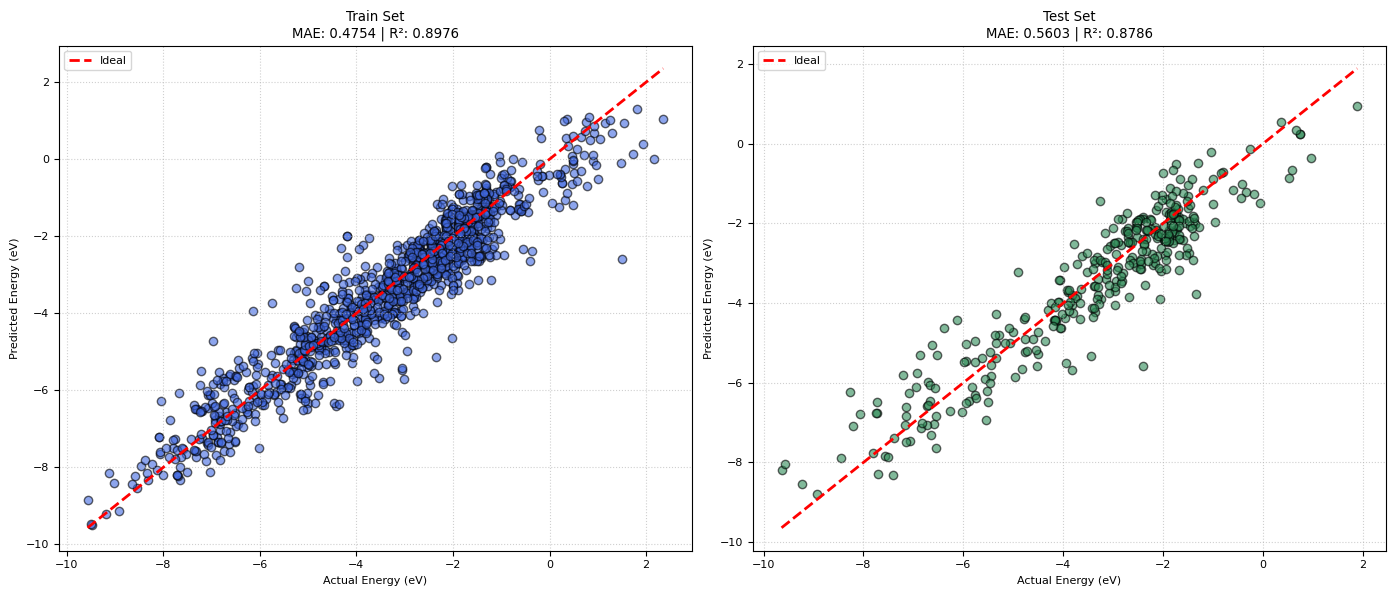


Training Complete. Final Test MAE: 0.5603 eV


In [31]:
import torch
import matplotlib.pyplot as plt

# --- 1. Configuration & Parameter Loading ---
#if 'best_params' in locals():
 #   best_feature_dim = best_params['feature_dim']
 #   best_hidden_dim = best_params['hidden_dim']
  #  best_num_layers = best_params['num_layers']
   # best_lr = best_params['lr']
    #print(f"Using best params: {best_params}")
#else:
 #   best_hidden_dim, best_num_layers, best_lr = 64, 2, 0.01
  #  print("Warning: best_params not found. Using manual defaults.")

#best_feature_dim = 64 #8
ELEMENT_EMBED_DIM = 16
MACE_DIM = 4
best_feature_dim = ELEMENT_EMBED_DIM + MACE_DIM  # = 20
best_hidden_dim = 256 #8
best_num_layers = 4 #1
best_lr = 0.01 #0.01

# --- 2. Initialize Model & Optimizer ---
model = GNNModel(
    feature_dim=best_feature_dim,
    hidden_dim=best_hidden_dim,
    output_dim=1,
    num_layers=best_num_layers
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)
loss_fn = torch.nn.MSELoss()

# --- 3. Training with Early Stopping ---
num_epochs = 100
patience = 7
best_val_mae = float('inf')
best_state = None
counter = 0

print(f'\nStarting final training (Max {num_epochs} epochs)...')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for graph in train_graphs:
        optimizer.zero_grad()
        pred = model(graph)
        loss = loss_fn(pred, graph.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_graphs)

    # --- Validation ---
    model.eval()
    val_targets = [g.y.item() for g in val_graphs]
    val_mae, _, _, _, _, _ = evaluate_model(model, val_graphs, val_targets)

    # --- Early Stopping ---
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Stopping early at epoch {epoch+1}. Restoring best weights.")
            model.load_state_dict(best_state)
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {avg_loss:.4f} | Val MAE: {val_mae:.4f}")

# --- 4. Final Evaluation ---
print("\n--- Final Evaluation ---")

train_targets = [g.y.item() for g in train_graphs]
test_targets = [g.y.item() for g in test_graphs]

train_metrics = evaluate_model(model, train_graphs, train_targets)
test_metrics = evaluate_model(model, test_graphs, test_targets)

train_mae, train_rmse, train_r2, train_max, train_preds, train_actuals = train_metrics
test_mae, test_rmse, test_r2, test_max, test_preds, test_actuals = test_metrics

# --- 5. Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def plot_parity(ax, actual, pred, mae, r2, title, color):
    ax.scatter(actual, pred, alpha=0.6, color=color, edgecolors='k')
    lims = [min(min(actual), min(pred)), max(max(actual), max(pred))]
    ax.plot(lims, lims, 'r--', lw=2, label='Ideal')
    ax.set_xlabel('Actual Energy (eV)')
    ax.set_ylabel('Predicted Energy (eV)')
    ax.set_title(f'{title}\nMAE: {mae:.4f} | R²: {r2:.4f}')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plot_parity(ax1, train_actuals, train_preds, train_mae, train_r2, "Train Set", "royalblue")
plot_parity(ax2, test_actuals, test_preds, test_mae, test_r2, "Test Set", "seagreen")

plt.tight_layout()
plt.show()

print(f"\nTraining Complete. Final Test MAE: {test_mae:.4f} eV")


In [46]:
def compute_site_adsorption_features(
    atoms_full,
    host_indices,
    mace_calc,
    probe_dict,
    relax_fmax=0.05,
    relax_steps=30
):
    num_atoms = len(atoms_full)
    num_probes = len(probe_dict)
    site_ads = torch.zeros(num_atoms, num_probes)

    # ---- 1. Isolate the bare surface ----
    ghit_temp = GHIT(atoms_full)
    ghit_temp.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])

    guest_indices = ghit_temp.get_guest_atoms() or []
    host_indices_all = [i for i in range(num_atoms) if i not in guest_indices]
    bare_surface = atoms_full[host_indices_all]

    # ---- 2. Bare surface energy (single-point) ----
    bare_surface.calc = mace_calc
    try:
        e_bare = bare_surface.get_potential_energy()
    except Exception as e:
        print("Bare surface energy failed:", e)
        e_bare = 0.0

    n_surface = len(bare_surface)

    # ---- 3. Probe each binding site ----
    for i in host_indices:
        pos = atoms_full.positions[i]

        for p_idx, (name, probe_atoms) in enumerate(probe_dict.items()):
            probe = probe_atoms.copy()

            # Initial placement above site
            probe.translate(pos + np.array([0.0, 0.0, 1.8]))

            combined = bare_surface + probe
            combined.calc = mace_calc

            # ---- Freeze surface, relax probe only ----
            surface_indices = list(range(n_surface))
            combined.set_constraint(FixAtoms(indices=surface_indices))

            try:
                opt = BFGS(combined, logfile=None)
                opt.run(fmax=relax_fmax, steps=relax_steps)

                e_int = combined.get_potential_energy() - e_bare
            except Exception as e:
                print(f"Relaxation failed for site {i}, probe {name}: {e}")
                e_int = 0.0

            site_ads[i, p_idx] = e_int

    return site_ads

In [ ]:
# 2. Define the Precalculation Logic (atom-level, no averaging)
def precalculate_mace_features(atoms_list, dataframe, mace_calculator):
    # Initialize probes
    probes = get_probe_adsorbates()
    mace_results = []

    print(f"Starting atom-resolved MACE probing for {len(atoms_list)} samples...")

    for sample_idx in tqdm(range(len(atoms_list))):
        atoms_example = atoms_list[sample_idx]

        # Identify binding site
        ghit = GHIT(atoms_example)
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        ghit.find_host_binding_atoms()

        # Flatten host binding atoms into a single list
        host_binding = [i for sub in ghit.get_host_binding_atoms() for i in sub]

        # Compute site-specific MACE features
        site_ads_tensor = compute_site_adsorption_features(
            atoms_example, host_binding, mace_calculator, probes
        )

        # Store features per binding atom
        for atom_idx in host_binding:
            atom_features = site_ads_tensor[atom_idx].numpy()
            mace_results.append({
                'sample_idx': sample_idx,
                'atom_idx': atom_idx,
                'element': atoms_example[atom_idx].symbol,
                'mace_H':   atom_features[0],
                'mace_OH':  atom_features[1],
                'mace_CH3': atom_features[2],
                'mace_NH2': atom_features[3]
            })

    return pd.DataFrame(mace_results)

# 3. RUN THE PIPELINE
# Make sure mace_calc is already initialized (e.g., mace_calc = MACECalculator(...))
mace_df = precalculate_mace_features(atomsList, df, mace_calc)

# --- NORMALIZATION ---
cols_to_norm = ['mace_H', 'mace_OH', 'mace_CH3', 'mace_NH2']
for col in cols_to_norm:
    mace_df[f'{col}_norm'] = (mace_df[col] - mace_df[col].mean()) / mace_df[col].std()

# Save to CSV
mace_df.to_csv("mace_descriptors_relaxed_atomwise.csv", index=False)
print("Saved mace_descriptors_relaxed_atomwise.csv successfully.")

In [ ]:
# 2. Define the Precalculation Logic
def precalculate_mace_features(atoms_list, dataframe, mace_calculator):
    # Initialize probes inside or pass them in
    probes = get_probe_adsorbates()
    mace_results = []

    print(f"Starting MACE virtual probing for {len(atoms_list)} samples...")
    
    for idx in tqdm(range(len(atoms_list))):
        atoms_example = atoms_list[idx]
        
        # Identify binding site
        ghit = GHIT(atoms_example)
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        ghit.find_host_binding_atoms()
        
        # Flatten host binding atoms into a single list
        host_binding = [i for sub in ghit.get_host_binding_atoms() for i in sub]
        
        # Run the MACE probing function we defined earlier
        # (Ensure compute_site_adsorption_features is defined in your notebook)
        site_ads_tensor = compute_site_adsorption_features(
            atoms_example, host_binding, mace_calculator, probes
        )
        
        # Extract mean values for the binding atoms
        if len(host_binding) > 0:
            site_values = site_ads_tensor[host_binding].mean(dim=0).numpy()
        else:
            site_values = np.zeros(len(probes))

        mace_results.append({
            'sample_idx': idx,
            'mace_H': site_values[0],
            'mace_OH': site_values[1],
            'mace_CH3': site_values[2],
            'mace_NH2': site_values[3]
        })

    return pd.DataFrame(mace_results)

# 3. RUN THE PIPELINE
# Make sure mace_calc is already initialized (e.g., mace_calc = MACECalculator(...))
mace_df = precalculate_mace_features(atomsList, df, mace_calc)

# --- NORMALIZATION ---
# Scaled features (Mean=0, Std=1) help the GNN learn much faster
cols_to_norm = ['mace_H', 'mace_OH', 'mace_CH3', 'mace_NH2']
for col in cols_to_norm:
    mace_df[f'{col}_norm'] = (mace_df[col] - mace_df[col].mean()) / mace_df[col].std()

# Save to CSV
mace_df.to_csv("mace_descriptors_relaxed.csv", index=False)
print("Saved mace_descriptors.csv successfully.")

Starting MACE virtual probing for 1750 samples...


  0%|                                                  | 0/1750 [00:00<?, ?it/s]/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True
 16%|█████▎                            | 275/1750 [4:00:40<71:17:20, 173.99s/it]

In [26]:
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from ase import Atoms

# 1. Define the Probes (The "sensors" for your surface)
def get_probe_adsorbates():
    return {
        "H":   Atoms("H", positions=[[0, 0, 0]]),
        "OH":  Atoms("OH", positions=[[0, 0, 0], [0, 0, 1.0]]),
        "CH3": Atoms("CH3", positions=[[0, 0, 0], [0, 0, 1.0], [1.0, 0, 0], [0, 1.0, 0]]),
        "NH2": Atoms("NH2", positions=[[0, 0, 0], [0, 0, 1.0], [1.0, 0, 0]])
    }

def compute_site_adsorption_features(atoms_full, host_indices, mace_calc, probe_dict):
    num_atoms = len(atoms_full)
    num_probes = len(probe_dict)
    site_ads = torch.zeros(num_atoms, num_probes)

    # 1. Isolate the bare surface
    ghit_temp = GHIT(atoms_full)
    ghit_temp.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
    
    # FIX: Ensure guest_indices is a list, even if empty
    guest_indices = ghit_temp.get_guest_atoms()
    if guest_indices is None:
        guest_indices = []
    
    # Now this list comprehension won't crash
    host_indices_all = [i for i in range(num_atoms) if i not in guest_indices]
    
    # Safety check: if atoms_full is already bare, host_indices_all will be all atoms
    bare_surface = atoms_full[host_indices_all]
    
    # 2. Get baseline energy of bare surface
    bare_surface.calc = mace_calc
    try:
        e_bare = bare_surface.get_potential_energy()
    except:
        e_bare = 0.0

    # 3. Probe each binding host atom
    for i in host_indices:
        pos = atoms_full.positions[i]
        
        for p_idx, (name, probe_atoms) in enumerate(probe_dict.items()):
            probe = probe_atoms.copy()
            # Position the probe 1.8A above the specific metal atom
            probe.translate(pos + np.array([0.0, 0.0, 1.8]))
            
            combined = bare_surface + probe
            combined.calc = mace_calc
            
            try:
                # Interaction Energy = E(Surface+Probe) - E(Surface)
                # This isolates the "strength" of that specific spot
                e_int = combined.get_potential_energy() - e_bare
            except:
                e_int = 0.0
            
            site_ads[i, p_idx] = e_int

    return site_ads
# 2. Define the Precalculation Logic
def precalculate_mace_features(atoms_list, dataframe, mace_calculator):
    # Initialize probes inside or pass them in
    probes = get_probe_adsorbates()
    mace_results = []

    print(f"Starting MACE virtual probing for {len(atoms_list)} samples...")
    
    for idx in tqdm(range(len(atoms_list))):
        atoms_example = atoms_list[idx]
        
        # Identify binding site
        ghit = GHIT(atoms_example)
        ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
        ghit.find_host_binding_atoms()
        
        # Flatten host binding atoms into a single list
        host_binding = [i for sub in ghit.get_host_binding_atoms() for i in sub]
        
        # Run the MACE probing function we defined earlier
        # (Ensure compute_site_adsorption_features is defined in your notebook)
        site_ads_tensor = compute_site_adsorption_features(
            atoms_example, host_binding, mace_calculator, probes
        )
        
        # Extract mean values for the binding atoms
        if len(host_binding) > 0:
            site_values = site_ads_tensor[host_binding].mean(dim=0).numpy()
        else:
            site_values = np.zeros(len(probes))

        mace_results.append({
            'sample_idx': idx,
            'mace_H': site_values[0],
            'mace_OH': site_values[1],
            'mace_CH3': site_values[2],
            'mace_NH2': site_values[3]
        })

    return pd.DataFrame(mace_results)

# 3. RUN THE PIPELINE
# Make sure mace_calc is already initialized (e.g., mace_calc = MACECalculator(...))
mace_df = precalculate_mace_features(atomsList, df, mace_calc)

# --- NORMALIZATION ---
# Scaled features (Mean=0, Std=1) help the GNN learn much faster
cols_to_norm = ['mace_H', 'mace_OH', 'mace_CH3', 'mace_NH2']
for col in cols_to_norm:
    mace_df[f'{col}_norm'] = (mace_df[col] - mace_df[col].mean()) / mace_df[col].std()

# Save to CSV
mace_df.to_csv("mace_descriptors.csv", index=False)
print("Saved mace_descriptors.csv successfully.")

Starting MACE virtual probing for 1750 samples...


100%|█████████████████████████████████████| 1750/1750 [2:12:35<00:00,  4.55s/it]

Saved mace_descriptors.csv successfully.


In [24]:
def setup_mace_calculator(model="medium", device="cpu"):
    """
    MACE expects device as a string: 'cpu', 'cuda', 'cuda:0'
    """
    if isinstance(device, torch.device):
        device = str(device)

    print(f"Setting up MACE-MP calculator on device='{device}'")
    return mace_mp(model=model, device=device)

In [25]:
from ase import Atoms
import torch
import numpy as np
from mace.calculators import mace_mp



def get_probe_adsorbates():
    """
    Simple radicals placed at top site.
    Energies are used as *interaction strength descriptors*.
    """
    return {
        "H":  Atoms("H", positions=[[0, 0, 0]]),
        "OH": Atoms("OH", positions=[[0, 0, 0], [0, 0, 1.0]]),
        "CH3": Atoms("CH3", positions=[[0, 0, 0],
                                       [0, 0, 1.0],
                                       [1.0, 0, 0],
                                       [0, 1.0, 0]]),
        "NH2": Atoms("NH2", positions=[[0, 0, 0],
                                       [0, 0, 1.0],
                                       [1.0, 0, 0]])
    }

In [26]:
def compute_site_adsorption_features(
    atoms,
    host_binding_atoms,
    mace_calc,
    probe_adsorbates,
):
    """
    Returns:
        site_ads: Tensor [num_atoms, num_probes]
                  Non-zero ONLY for host_binding atoms
    """
    num_atoms = len(atoms)
    num_probes = len(probe_adsorbates)
    site_ads = torch.zeros(num_atoms, num_probes)

    for i in host_binding_atoms:
        pos = atoms.positions[i]

        for p_idx, probe in enumerate(probe_adsorbates.values()):
            probe = probe.copy()
            probe.translate(pos + np.array([0.0, 0.0, 1.8]))  # top site guess

            combined = atoms + probe
            combined.calc = mace_calc

            try:
                energy = combined.get_potential_energy()
            except Exception:
                energy = 0.0  # fail-safe

            site_ads[i, p_idx] = energy

    return site_ads

In [ ]:
device = torch.device("cpu")

mace_calc = setup_mace_calculator(device=device)
probe_adsorbates = get_probe_adsorbates()

graphs = []
targets = []

for idx in range(len(atomsList)):
    atoms_example = atomsList[idx]
    target_energy = df.iloc[idx]["adsorption_energy"]
    targets.append(target_energy)

    edges = make_edge_list(atoms_example)

    ghit = GHIT(atoms_example)
    ghit.find_guest_atoms(guest_elements=['C','O','H','N','F','S','K'])
    guest_atoms = set(ghit.get_guest_atoms())
    host_atoms = set(range(len(atoms_example))) - guest_atoms

    ghit.find_guest_binding_atoms()
    ghit.find_host_binding_atoms()

    guest_binding = set(ghit.get_guest_binding_atoms())
    host_binding = set()
    for hb in ghit.get_host_binding_atoms():
        host_binding.update(hb)

    node_types = []
    for i in range(len(atoms_example)):
        if i in host_atoms:
            node_types.append(1 if i in host_binding else 0)
        else:
            node_types.append(3 if i in guest_binding else 2)

    site_ads = compute_site_adsorption_features(
        atoms_example,
        host_binding,
        mace_calc,
        probe_adsorbates
    )

    edge_index = torch.tensor([[e[0], e[1]] for e in edges], dtype=torch.long).t()
    edge_type = torch.tensor(
        [{"SS":0, "AA":1, "SA_bond":2}[e[2]] for e in edges],
        dtype=torch.long
    )

    graph = GraphSample(
        x=torch.empty(len(atoms_example), 0),
        edge_index=edge_index,
        edge_type=edge_type,
        node_type=torch.tensor(node_types),
        site_ads=site_ads,
        atoms=atoms_example,
        y=torch.tensor([target_energy], dtype=torch.float)
    ).to(device)

    graphs.append(graph)

print(f"Created {len(graphs)} graphs")

Setting up MACE-MP calculator on device='cpu'
Using Materials Project MACE for MACECalculator with /Users/hajar/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.


/opt/anaconda3/envs/gcnn_safe_cpu/lib/python3.10/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:22: FutureWarning: Please use atoms.calc
  calculator=args[0].get_calculator(),
/Users/hajar/Downloads/montemoregroup1/src/montegroup/ghit.py:115: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  range(self.get_number_of_atoms()), guest_atoms, assume_unique=True
